In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn

In [76]:
device = torch.device("cuda")

In [77]:
torch.cuda.is_available()

True

In [78]:
torch.cuda.get_device_name()

'NVIDIA GeForce RTX 5050 Laptop GPU'

In [79]:
from torch.utils.data import DataLoader
from torchvision import datasets,transforms

In [80]:
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

train = datasets.ImageFolder(
    "./tiny-imagenet/train",
    transform = transform
)

test = datasets.ImageFolder(
    "./tiny-imagenet/test",
    transform = transform
)

train_loader = DataLoader(
    dataset=train,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test,
    batch_size=32,
    shuffle=True
)


In [81]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super(AutoEncoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), # Increased channels
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), # Wider bottleneck
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 2, stride=2),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),
            nn.Conv2d(128, 128, 3, padding=1), 
            nn.LeakyReLU(0.1),
            nn.ConvTranspose2d(128, 64, 2, stride=2),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
            nn.Conv2d(64, 64, 3, padding=1),  
            nn.LeakyReLU(0.1),
            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1),
            nn.Conv2d(32, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [82]:
from torch.optim import Adam

model = AutoEncoder().to(device)

optimizer = Adam(model.parameters(),lr=1e-2)
Epochs = 50
criterion = nn.MSELoss()

for epoch in range(Epochs):
    for images,labels in train_loader:
        image = images.to(device)
        optimizer.zero_grad()
        output = model(image)
        loss = criterion(output,image)
        loss.backward()
        optimizer.step()
    print(f"epoch number {epoch} is done")

epoch number 0 is done
epoch number 1 is done
epoch number 2 is done
epoch number 3 is done
epoch number 4 is done
epoch number 5 is done
epoch number 6 is done
epoch number 7 is done
epoch number 8 is done
epoch number 9 is done
epoch number 10 is done
epoch number 11 is done
epoch number 12 is done
epoch number 13 is done
epoch number 14 is done
epoch number 15 is done
epoch number 16 is done
epoch number 17 is done
epoch number 18 is done
epoch number 19 is done
epoch number 20 is done
epoch number 21 is done
epoch number 22 is done
epoch number 23 is done
epoch number 24 is done
epoch number 25 is done
epoch number 26 is done
epoch number 27 is done
epoch number 28 is done
epoch number 29 is done
epoch number 30 is done
epoch number 31 is done
epoch number 32 is done
epoch number 33 is done
epoch number 34 is done
epoch number 35 is done
epoch number 36 is done
epoch number 37 is done
epoch number 38 is done
epoch number 39 is done
epoch number 40 is done
epoch number 41 is done
ep

In [83]:
from torchmetrics.image import StructuralSimilarityIndexMeasure

ssim_metric = StructuralSimilarityIndexMeasure().to(device)

model.eval()
with torch.no_grad():
    for images,labesl in test_loader:      
        outputs = model(images.to(device))
    
    score = ssim_metric(outputs, images.to(device))
    print(f"SSIM Score: {score.item():.4f}")


SSIM Score: 0.6557


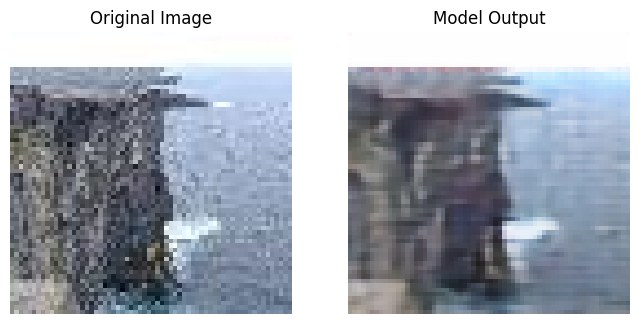

In [84]:
images,labels = next(iter(test_loader))

single_image = images[0].unsqueeze(0).to(device)
output = 0
with torch.no_grad():
    output = model(single_image)

original = single_image.squeeze(0).to("cpu")
reconstructed = output.squeeze(0).to("cpu")

fig, axes = plt.subplots(1, 2, figsize=(8, 4)) 
axes[0].imshow(original.permute(1, 2, 0)) # this is just because matplotlib wants the format to be LxBxH
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(reconstructed.permute(1, 2, 0))
axes[1].set_title("Model Output")
axes[1].axis('off')

plt.show()

In [85]:
from torch.optim import Adam

model = AutoEncoder().to(device)

optimizer = Adam(model.parameters(), lr=1e-3)
Epochs = 50
criterion = nn.MSELoss()
def gb(images, mean=0.0, std=0.1):
    noise = torch.randn_like(images) * std + mean
    noisy = images + noise
    return torch.clamp(noisy, 0.0, 1.0)

for epoch in range(Epochs):
    for images, labels in train_loader:
        image = images.to(device)
        optimizer.zero_grad()
        blurimg = gb(image)
        blurimg = blurimg.to(device)
        output = model(blurimg)
        loss = criterion(output, image)
        loss.backward()
        optimizer.step()
    print(f"epoch number {epoch} is done")

epoch number 0 is done
epoch number 1 is done
epoch number 2 is done
epoch number 3 is done
epoch number 4 is done
epoch number 5 is done
epoch number 6 is done
epoch number 7 is done
epoch number 8 is done
epoch number 9 is done
epoch number 10 is done
epoch number 11 is done
epoch number 12 is done
epoch number 13 is done
epoch number 14 is done
epoch number 15 is done
epoch number 16 is done
epoch number 17 is done
epoch number 18 is done
epoch number 19 is done
epoch number 20 is done
epoch number 21 is done
epoch number 22 is done
epoch number 23 is done
epoch number 24 is done
epoch number 25 is done
epoch number 26 is done
epoch number 27 is done
epoch number 28 is done
epoch number 29 is done
epoch number 30 is done
epoch number 31 is done
epoch number 32 is done
epoch number 33 is done
epoch number 34 is done
epoch number 35 is done
epoch number 36 is done
epoch number 37 is done
epoch number 38 is done
epoch number 39 is done
epoch number 40 is done
epoch number 41 is done
ep

In [86]:
from torchmetrics.image import StructuralSimilarityIndexMeasure
ssim_metric = StructuralSimilarityIndexMeasure().to(device)
model.eval()
with torch.no_grad():
    for images, _ in test_loader:                 
        fakeimg = gb(images).to(device)
        outputs = model(fakeimg)
        ssim_metric.update(outputs, images.to(device))  

score = ssim_metric.compute()                      
print(f"SSIM Score: {score.item():.4f}")

SSIM Score: 0.6942


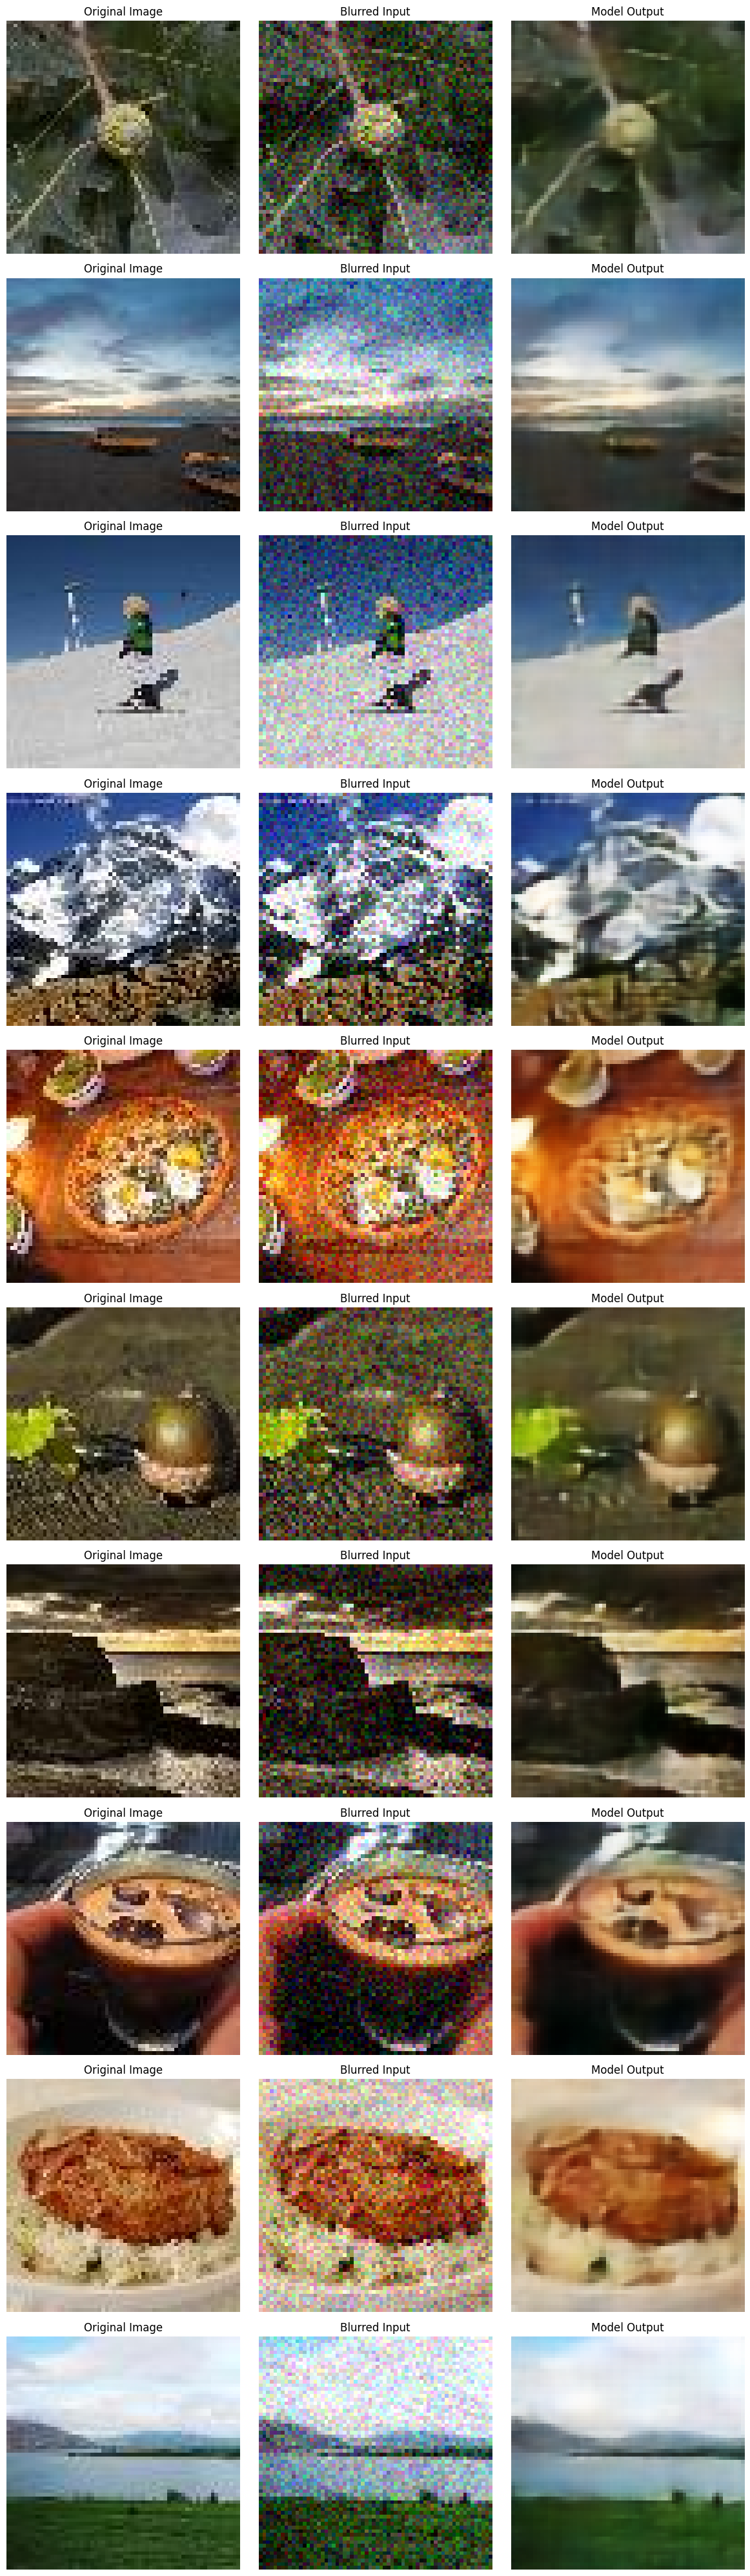

In [87]:
images, labels = next(iter(test_loader))
sample_images = images[:10].to(device)        
reconstructed_list = []
blurred_list = []

with torch.no_grad():
    for i in range(10):
        single_image = sample_images[i].unsqueeze(0)
        blurimg = gb(single_image).to(device)
        output = model(blurimg)
        blurred_list.append(blurimg.squeeze(0).cpu())        
        reconstructed_list.append(output.squeeze(0).cpu())  

fig, axes = plt.subplots(10, 3, figsize=(12, 40))

for i in range(10):
    axes[i, 0].imshow(images[i].permute(1, 2, 0))
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(blurred_list[i].permute(1, 2, 0))  
    axes[i, 1].set_title("Blurred Input")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(reconstructed_list[i].permute(1, 2, 0))
    axes[i, 2].set_title("Model Output")
    axes[i, 2].axis('off')
plt.tight_layout()
plt.show()